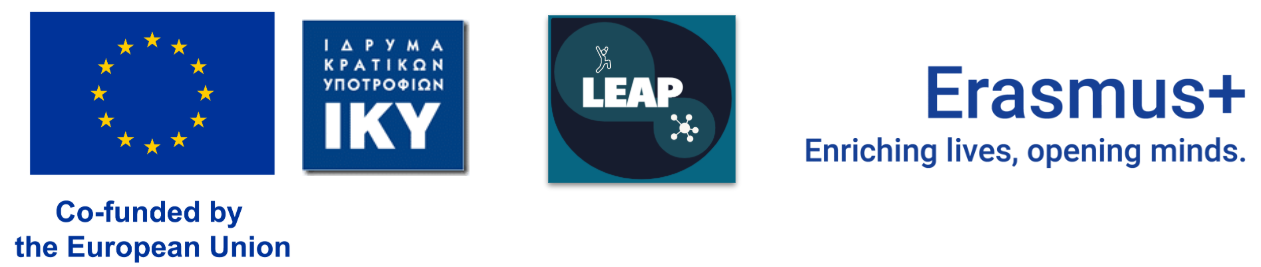

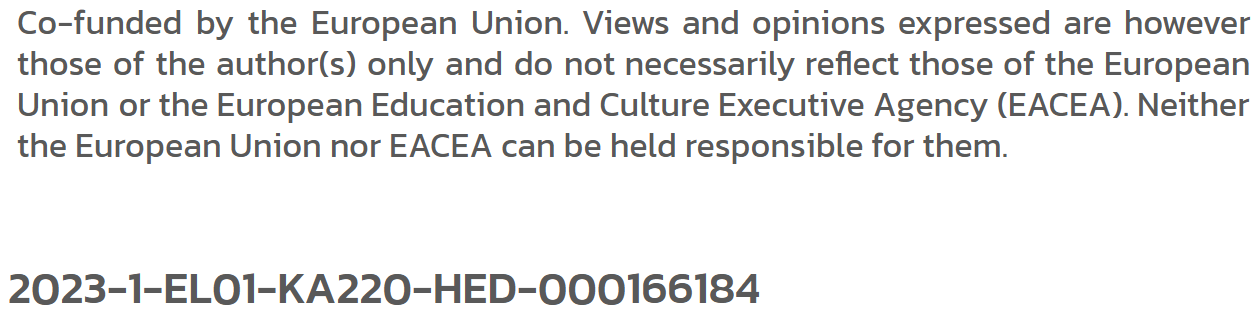

# Final Project, Option 3: How much structure can you find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project you recover that structure using clustering alone.

In this project you take a data set with a known grouping, hide that grouping from yourself, and see how much of it you can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can you recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. You are given the measurements to work with, and the variety labels are set aside for the final check.

This project draws on Module 4. There we scaled features, reduced them with PCA, clustered with K-Means, chose the number of clusters using the elbow and silhouette methods, and validated the result against a known label with a cross-tabulation. Here you carry out that whole process yourself and judge how faithfully the clusters match the real varieties.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the scaling. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order, and resist looking at the varieties until Part D.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading the data

We download the Seeds data set. The seven measurements go into `X`, and the true varieties go into `y_true`. We put the varieties aside now and do not touch them until Part D, so that the clustering is done with no knowledge of the answer.

In [49]:
# The Seeds data set: 210 kernels described by seven geometric measurements.
# It is small and fully numeric,
# which suits clustering well.
feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds = fetch_openml(name="seeds", version=1, as_frame=True)

X = seeds.data.copy()
X.columns = feature_names          # give the seven measurements readable names

# The true varieties. We set these aside now and do NOT use them until Part D,
# where they serve only as an external check on the clustering.
y_true = seeds.target.to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()

Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features

Clustering relies on distances between points, so a feature measured on a larger scale would count for more than the others. We put every feature on the same footing with `StandardScaler`, as in Module 4.

In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels

From here on, the cells are yours to complete.

First, look at the shape of the data. Seven measurements are too many to plot at once, so reduce them to two with PCA and draw a scatter. This is the same reduction you used in Module 4.

Explained variance ratio: [0.71874303 0.17108184]
Total variance explained by PC1 + PC2: 0.8898248618491232


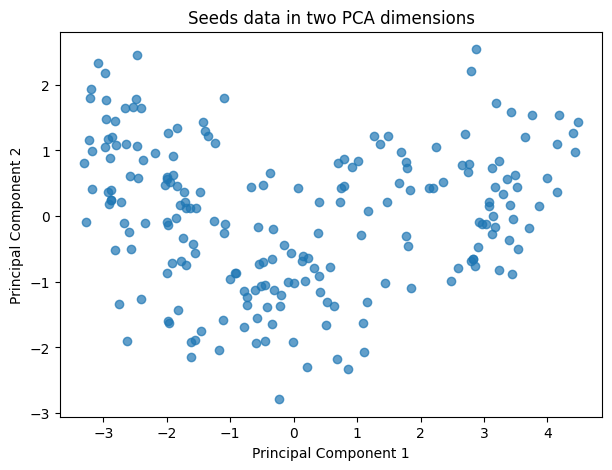

In [51]:
# Reduce the seven features to two so the data can be drawn on a flat plot.
pca = PCA(n_components=2)
X2 = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1 + PC2:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Seeds data in two PCA dimensions")
plt.show()


### What do you see?

The PCA scatter suggests about three broad regions in the data, but they are not completely separate. Two of the apparent groups overlap around the centre-left of the plot, so the number of clusters is not obvious from the scatter alone.


## Part C. Cluster and choose the number of groups

Now decide how many clusters the data supports, using the two methods from Module 4. The elbow method looks at inertia, the total spread of points around their cluster centres, and finds where adding another cluster stops helping much. The silhouette score measures how well separated the clusters are, where higher is better.

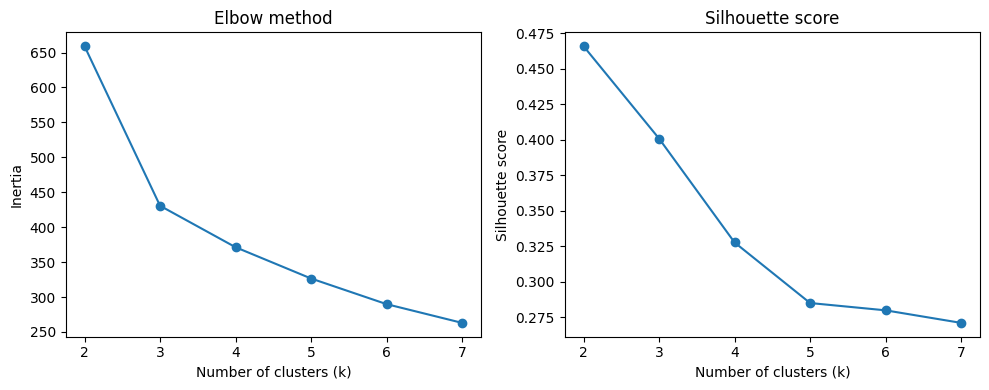

k=2: inertia=659.17, silhouette=0.466
k=3: inertia=430.66, silhouette=0.401
k=4: inertia=371.30, silhouette=0.328
k=5: inertia=326.51, silhouette=0.285
k=6: inertia=289.80, silhouette=0.280
k=7: inertia=262.97, silhouette=0.271


In [52]:
# Compare possible values of k with the elbow and silhouette methods.
ks = range(2, 8)
inertias = []
silhouettes = []

for k_test in ks:
    model = KMeans(n_clusters=k_test, n_init=10, random_state=42)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(ks), silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")

plt.tight_layout()
plt.show()

for k_test, inertia, sil in zip(ks, inertias, silhouettes):
    print(f"k={k_test}: inertia={inertia:.2f}, silhouette={sil:.3f}")


### How many clusters?

The silhouette score is highest for **k = 2**, but the elbow curve shows a strong improvement up to about **k = 3** and then becomes much flatter. I will therefore use **k = 3**, because it captures the additional visible structure while still keeping the solution simple.


### Fit K-Means

Fit K-Means at the number of clusters you decided on, and keep the cluster assignment for each kernel.

In [53]:
# Fit K-Means using the chosen number of clusters.
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(X_scaled)
labels = km.labels_

print("Chosen k:", k)
print("Cluster sizes:", np.bincount(labels))


Chosen k: 3
Cluster sizes: [72 67 71]


## Part D. Judge against the labels

We now bring in the true varieties for the first time, only as an external check. The clustering itself is finished; nothing below changes it. We simply ask how well the groups you found line up with the real varieties, exactly as we validated the clusters in Module 4.

In [54]:
# Reveal the varieties only now, after the clustering is complete.
print("Varieties present:", np.unique(y_true))

# Cross-tabulate cluster labels against the true varieties.
ct = pd.crosstab(labels, y_true)

print("\nCluster by true variety cross-tabulation:")
print(ct)


Varieties present: [1 2 3]

Cluster by true variety cross-tabulation:
col_0   1   2   3
row_0            
0       6   0  66
1       2  65   0
2      62   5   4


### Measuring the agreement

Turn the table into a single number with a purity score. For each cluster, take the count of its most common variety; add those counts across all clusters; then divide by the total number of kernels. A value near 1 means each cluster is almost entirely one variety.

Purity tends to increase when more clusters are created, so interpret it together with your chosen value of `k` and the cross-tabulation rather than using it on its own.

In [55]:
# Compute purity from the cross-tabulation.
purity = ct.max(axis=1).sum() / ct.values.sum()
print(f"Purity score: {purity:.3f}")


Purity score: 0.919


### Back to the picture

Connect the numbers to the shape you saw earlier. Redraw the PCA scatter, but this time colour each point by its true variety. Interpret this picture cautiously: K-Means used all seven scaled features, while the plot shows only two PCA dimensions. Points that overlap here may still be separated by information in the other dimensions.

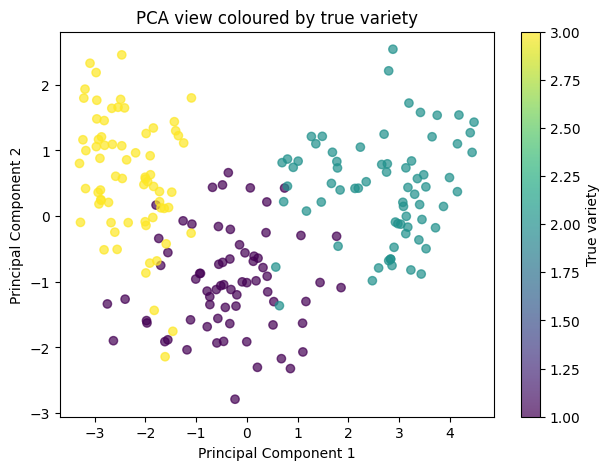

In [56]:
# Redraw the PCA scatter, now coloured by the true varieties.
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA view coloured by true variety")
cbar = plt.colorbar(scatter)
cbar.set_label("True variety")
plt.show()


### What each cluster captured

Finally, see what each cluster actually represents. The cluster centres are stored in scaled units, so turn them back into the original measurements with `scaler.inverse_transform`, and read across each row to picture the typical kernel in that group.

In [57]:
# Convert the fitted cluster centres back to the original measurement units.
centres_original = scaler.inverse_transform(km.cluster_centers_)
cluster_profiles = pd.DataFrame(centres_original, columns=feature_names)
cluster_profiles.index.name = "cluster"
print(cluster_profiles.round(3))


           area  perimeter  compactness  kernel_length  kernel_width  \
cluster                                                                
0        11.857     13.248        0.848          5.232         2.850   
1        18.495     16.203        0.884          6.176         3.698   
2        14.438     14.338        0.882          5.515         3.259   

         asymmetry  groove_length  
cluster                            
0            4.742          5.102  
1            3.632          6.042  
2            2.707          5.121  


### Ethical considerations

The clusters should not be treated as definite wheat varieties just because K-Means produced three groups. A purity of about 0.92 is strong but still leaves some kernels mixed between groups, and the fact that the silhouette score preferred two clusters shows that the structure is not perfectly clear. If the co-op used these clusters as certain labels, some kernels could be sorted or valued incorrectly, so laboratory or labelled validation would still be needed before operational use.


## Wrapping up

The diagnostics gave slightly different messages: the silhouette score was highest for **k = 2** (about 0.466), while the elbow curve showed a clear reduction in inertia up to **k = 3** and then a much smaller improvement. I therefore chose **three clusters**. After revealing the true labels, the cross-tabulation showed that the clusters matched the real varieties quite well, with a **purity score of about 0.919**, meaning 193 of the 210 kernels belonged to the majority variety of their cluster. Variety 2 formed the cleanest cluster, while varieties 1 and 3 showed the greatest overlap; the coloured PCA scatter supports this because variety 2 is visually more distinct and the other two meet in part of the plot. Even so, the PCA figure must be interpreted cautiously because it shows only two components, whereas K-Means used all seven scaled measurements, so some separation can exist in dimensions that are not visible in the two-dimensional plot.
